In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

%matplotlib widget

In [2]:
### file to do
fname = 'mastu_dalpha_filter_filt1.DAT'

### empty array for results
foutput = []
### iterate over lines in file and append to result list
with open(fname, 'r') as file:
    for line in file:
        foutput.append(line.strip())

### need to specify first row
foutput = foutput[227:]
### empty arrays for results
wl = np.zeros(len(foutput))
data = np.zeros((len(foutput), 10))

### iterate
for i in range(0, len(foutput)):
    #### tab delimeted, so split into a list
    line = foutput[i].split('\t')
    ### wavelength is the zeroth 
    wl[i] = float(line[0])
    ### data is from 1 every 3
    data[i] = np.asarray(line[1::3]).astype(float)

dataMean = data.mean(axis=1)
dataStd = data.std(axis=1)

In [3]:
### file to do
fname2 = 'mastu_dalpha_filter_ref1.DAT'

### empty array for results
foutput2 = []
### iterate over lines in file and append to result list
with open(fname2, 'r') as file:
    for line in file:
        foutput2.append(line.strip())

### need to specify first row
foutput2 = foutput2[227:]
### empty arrays for results
wl2 = np.zeros(len(foutput2))
data2 = np.zeros((len(foutput2), 10))

### iterate
for i in range(0, len(foutput2)):
    #### tab delimeted, so split into a list
    line = foutput2[i].split('\t')
    ### wavelength is the zeroth 
    wl2[i] = float(line[0])
    ### data is from 1 every 3
    data2[i] = np.asarray(line[1::3]).astype(float)

data2Mean = data2.mean(axis=1)
data2Std = data2.std(axis=1)

In [4]:
dx = 2.
xlim = (wl.min()-dx, wl.max()+dx)
xlim0 = (wl.min()-dx, wl.max()+dx+dx)

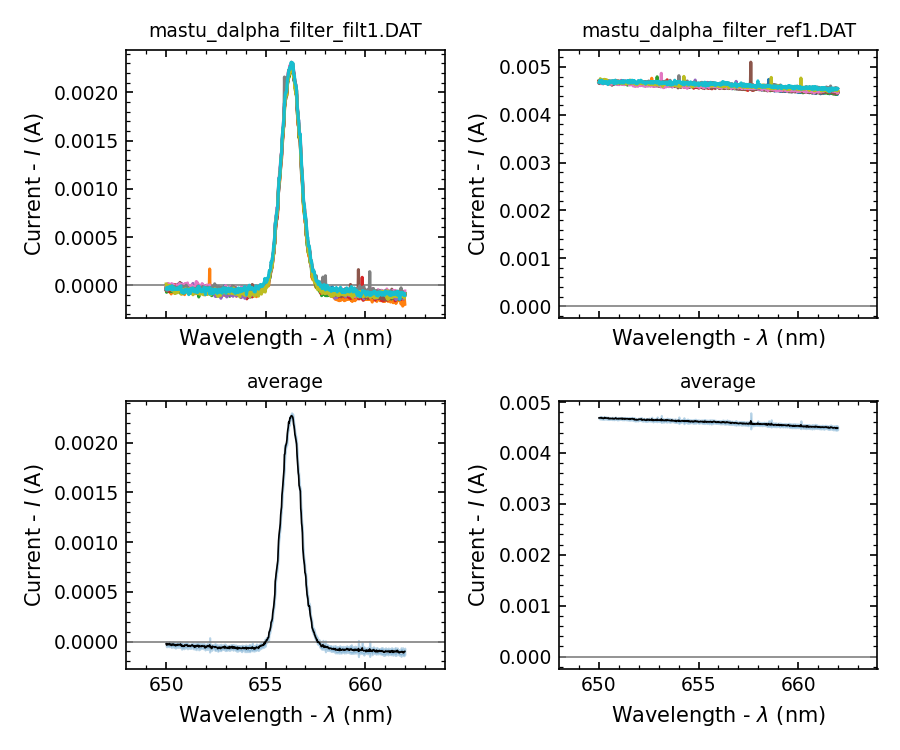

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(6,5), dpi=150, sharex=True)
ax[0,0].plot(xlim, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0,0].plot(wl, data[:,i])
ax[0,0].set_xlim(xlim)
ax[0,0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0,0].set_ylabel('Current - $I$ (A)')
ax[0,0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0,0].minorticks_on()
ax[0,0].set_title(f'{fname}', fontsize=9)


ax[1,0].plot(xlim, [0.,0.], '-', c='gray', lw=0.8)
ax[1,0].plot(wl, dataMean, '-k', lw=0.8)
ax[1,0].fill_between(
    wl, dataMean-dataStd, dataMean+dataStd, color='C0', alpha=0.3
)
ax[1,0].set_xlim(xlim)
ax[1,0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1,0].set_ylabel('Current - $I$ (A)')
ax[1,0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1,0].minorticks_on()
ax[1,0].set_title(f'average', fontsize=9)


ax[0,1].plot(xlim, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0,1].plot(wl2, data2[:,i])
ax[0,1].set_xlim(xlim)
ax[0,1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0,1].set_ylabel('Current - $I$ (A)')
ax[0,1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0,1].minorticks_on()
ax[0,1].set_title(f'{fname2}', fontsize=9)


ax[1,1].plot(xlim, [0.,0.], '-', c='gray', lw=0.8)
ax[1,1].plot(wl2, data2Mean, '-k', lw=0.8)
ax[1,1].fill_between(
    wl2, data2Mean-data2Std, data2Mean+data2Std, color='C0', alpha=0.3
)
ax[1,1].set_xlim(xlim)
ax[1,1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1,1].set_ylabel('Current - $I$ (A)')
ax[1,1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1,1].minorticks_on()
ax[1,1].set_title(f'average', fontsize=9)


plt.tight_layout()
plt.savefig('./Plots/results_unadjusted.png')

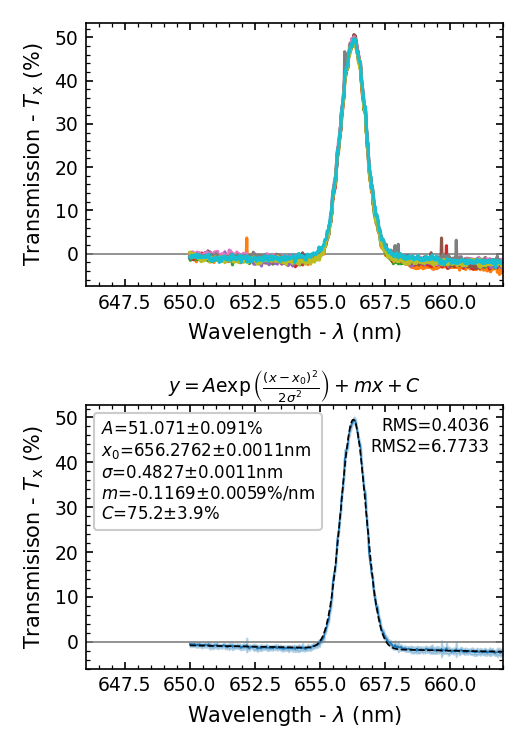

In [6]:
tx = data / data2

txMean = tx.mean(axis=1)
txStd = tx.std(axis=1)

def fitfunc(x, A, x0, sigma, m, C):
    return (A * np.exp(-(x - x0)**2 / (2. * sigma**2))) + (m * x) + C


popt, pcov = curve_fit(
    fitfunc, wl, txMean*100., sigma=txStd*100., 
    absolute_sigma=True, p0=(50., 656.1, 1.5, -0.125, 81.)
)

pcov = np.sqrt(np.diag(pcov))
fit = fitfunc(wl, *popt)

sf = 2
dp = np.zeros(len(popt)).astype(int)
for i in range(0, len(popt)):
    dp[i] = sf - int(np.floor(np.log10(pcov[i]))) - 1

xlim2 = (646.,662.)
    

RMS = np.sqrt(np.mean(np.abs(fit - (txMean * 100.))**2))
RMS2 = np.sqrt(np.mean(np.abs((fit - (txMean * 100.)) / (txMean * 100.))**2))


####################################################################################


fig, ax = plt.subplots(2, 1, figsize=(3.5,5), dpi=150)
ax[0].plot(xlim2, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0].plot(wl, tx[:,i] * 100.)
ax[0].set_xlim(xlim2)
ax[0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0].set_ylabel('Transmission - $T_\\mathrm{x}$ (%)')
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()


ax[1].plot(xlim2, [0.,0.], '-', c='gray', lw=0.8)
ax[1].plot(wl, txMean * 100., '-', c='C0', lw=0.8)
ax[1].fill_between(
    wl, (txMean-txStd)*100., (txMean+txStd)*100., color='C0', alpha=0.3
)
ax[1].plot(
    wl, fit, '--', c='k', lw=0.8, 
    label=f'$A$={popt[0]:.{dp[0]}f}$\\pm${pcov[0]:.{dp[0]}f}%\n' + \
    f'$x_0$={popt[1]:.{dp[1]}f}$\\pm${pcov[1]:.{dp[1]}f}nm\n' + \
    f'$\\sigma$={popt[2]:.{dp[2]}f}$\\pm${pcov[2]:.{dp[2]}f}nm\n' + \
    f'$m$={popt[3]:.{dp[3]}f}$\\pm${pcov[3]:.{dp[3]}f}%/nm\n' + \
    f'$C$={popt[4]:.{dp[4]}f}$\\pm${pcov[4]:.{dp[4]}f}%'
)
ax[1].set_xlim(xlim2)
ax[1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1].set_ylabel('Transmisison - $T_\\mathrm{x}$ (%)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax[1].set_title('$y=A\\exp\\left(\\frac{(x-x_0)^2}{2\\sigma^2}\\right) + mx + C$', fontsize=9)
ax[1].text(661.5, 50., f'RMS={RMS:.4f}\nRMS2={RMS2:.4f}', ha='right', va='top', fontsize=8)


plt.tight_layout()
plt.savefig('./Plots/results_transmission_unadjusted.png')

In [7]:
np.savez(
    '/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andoverCCFE_unadjusted.npz', 
    wavelength = wl,
    transmission = txMean * 100.,
    transmissionStd = txStd * 100.,
)

In [8]:
### file to do
fname3 = 'mastu_dalpha_filter_bg1.DAT'

### empty array for results
foutput3 = []
### iterate over lines in file and append to result list
with open(fname3, 'r') as file:
    for line in file:
        foutput3.append(line.strip())

### need to specify first row
foutput3 = foutput3[227:]
### empty arrays for results
wl3 = np.zeros(len(foutput3))
data3 = np.zeros((len(foutput3), 10))

### iterate
for i in range(0, len(foutput3)):
    #### tab delimeted, so split into a list
    line = foutput3[i].split('\t')
    ### wavelength is the zeroth 
    wl3[i] = float(line[0])
    ### data is from 1 every 3
    data3[i] = np.asarray(line[1::3]).astype(float)

data3Mean0 = data3.mean(axis=1)
data3Std0 = data3.std(axis=1)

data3Mean = data3[:,1:].mean(axis=1)
data3Std = data3[:,1:].std(axis=1)

In [9]:
def linfunc(x, m, C):
    return m * x + C

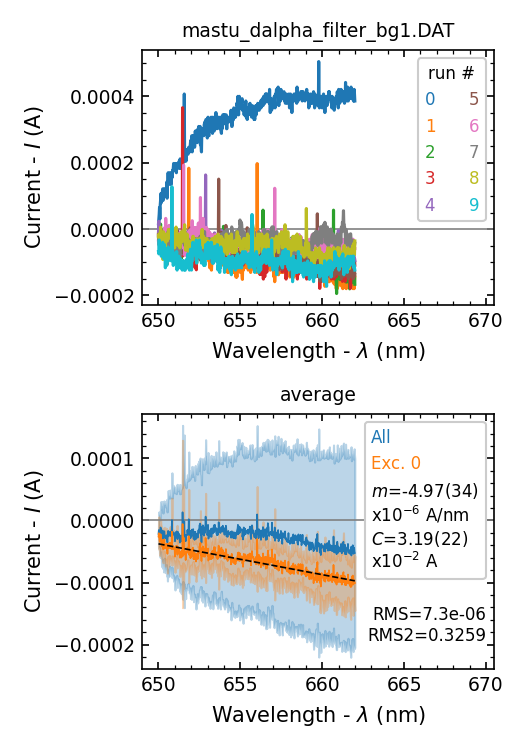

In [10]:
popt0, pcov0 = curve_fit(
    linfunc, wl3, data3Mean, sigma=data3Std, 
    absolute_sigma=True, p0=(-0.125, 81.5)
)
pcov0 = np.sqrt(np.diag(pcov0))
fit0 = linfunc(wl3, *popt0)

sf = 2
dp = np.zeros(len(popt0)).astype(int)
for i in range(0, len(popt0)):
    dp[i] = sf - int(np.floor(np.log10(pcov0[i]))) - 1

xlim0 = (wl.min()-1., 670.5)


RMS0 = np.sqrt(np.mean(np.abs(fit0 - (data3Mean))**2))
RMS20 = np.sqrt(np.mean(np.abs((fit0 - (data3Mean)) / (data3Mean))**2))

fig, ax = plt.subplots(2, 1, figsize=(3.5,5), dpi=150)
ax[0].plot(xlim0, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0].plot(wl3, data3[:,i], label=f'{i}')
ax[0].set_xlim(xlim0)
ax[0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0].set_ylabel('Current - $I$ (A)')
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].legend(
    fancybox=1, framealpha=1, fontsize=8, 
    ncol=2, title='run #', title_fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax[0].set_title(f'{fname3}', fontsize=9)


ax[1].plot(xlim0, [0.,0.], '-', c='gray', lw=0.8)
ax[1].plot(wl3, data3Mean0, '-', c='C0', lw=0.8, label='All')
ax[1].fill_between(
    wl3, data3Mean0-data3Std0, data3Mean0+data3Std0, color='C0', alpha=0.3
)
ax[1].plot(wl3, data3Mean, '-', c='C1', lw=0.8, label='Exc. 0')
ax[1].fill_between(
    wl3, data3Mean-data3Std, data3Mean+data3Std, color='C1', alpha=0.3
)
# ax[1].plot(
#     wl3, fit, '--', c='k', lw=0.8, 
#     label=f'$m$={popt0[0]:.3g}$\\pm${pcov0[0]:.2g} A/nm\n' + \
#     f'$C$={popt0[1]:.3g}$\\pm${pcov0[1]:.2g} A\n'
# )
ax[1].plot(
    wl3, fit0, '--', c='k', lw=0.8, 
    label=f'$m$=-4.97(34)\nx10$^{{-6}}$ A/nm\n' + \
    f'$C$=3.19(22)\nx10$^{{-2}}$ A'
)
ax[1].set_xlim(xlim0)
ax[1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1].set_ylabel('Current - $I$ (A)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax[1].text(670, -0.0002, f'RMS={RMS0:.2g}\nRMS2={RMS20:.4f}', ha='right', va='bottom', fontsize=8)
ax[1].set_title(f'average', fontsize=9)

                
plt.tight_layout()
plt.savefig('./Plots/background.png')

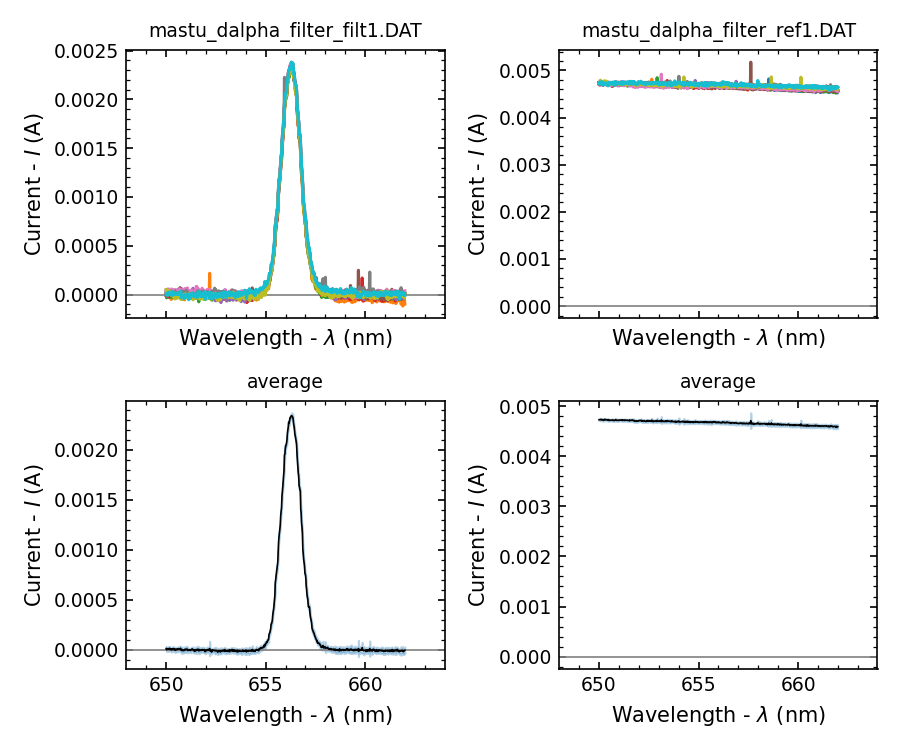

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(6,5), dpi=150, sharex=True)
ax[0,0].plot(xlim, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0,0].plot(wl, data[:,i] - fit0)
ax[0,0].set_xlim(xlim)
ax[0,0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0,0].set_ylabel('Current - $I$ (A)')
ax[0,0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0,0].minorticks_on()
ax[0,0].set_title(f'{fname}', fontsize=9)


ax[1,0].plot(xlim, [0.,0.], '-', c='gray', lw=0.8)
ax[1,0].plot(wl, dataMean - fit0, '-k', lw=0.8)
ax[1,0].fill_between(
    wl, dataMean-dataStd - fit0, dataMean+dataStd - fit0, color='C0', alpha=0.3
)
ax[1,0].set_xlim(xlim)
ax[1,0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1,0].set_ylabel('Current - $I$ (A)')
ax[1,0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1,0].minorticks_on()
ax[1,0].set_title(f'average', fontsize=9)


ax[0,1].plot(xlim, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0,1].plot(wl2, data2[:,i] - fit0)
ax[0,1].set_xlim(xlim)
ax[0,1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0,1].set_ylabel('Current - $I$ (A)')
ax[0,1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0,1].minorticks_on()
ax[0,1].set_title(f'{fname2}', fontsize=9)


ax[1,1].plot(xlim, [0.,0.], '-', c='gray', lw=0.8)
ax[1,1].plot(wl2, data2Mean - fit0, '-k', lw=0.8)
ax[1,1].fill_between(
    wl2, data2Mean-data2Std - fit0, data2Mean+data2Std - fit0, color='C0', alpha=0.3
)
ax[1,1].set_xlim(xlim)
ax[1,1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1,1].set_ylabel('Current - $I$ (A)')
ax[1,1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1,1].minorticks_on()
ax[1,1].set_title(f'average', fontsize=9)


plt.tight_layout()
plt.savefig('./Plots/results_adjusted.png')

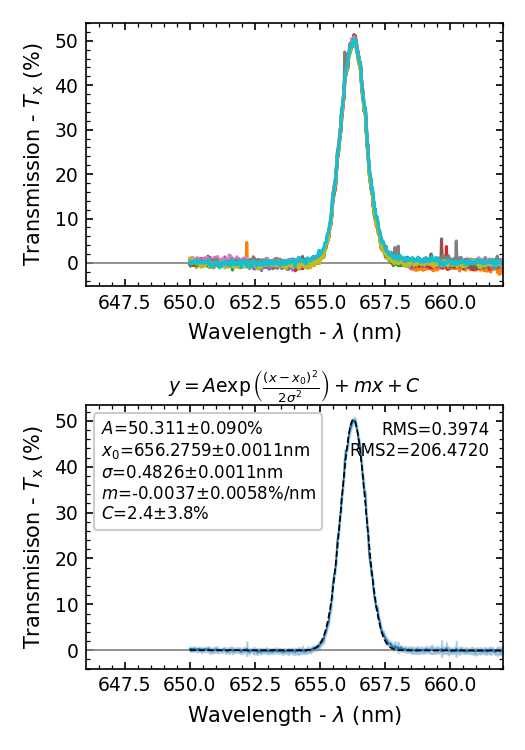

In [12]:
tx = (data - fit0[:,np.newaxis]) / (data2 - fit0[:,np.newaxis])

txMean = tx.mean(axis=1)
txStd = tx.std(axis=1)

def fitfunc(x, A, x0, sigma, m, C):
    return (A * np.exp(-(x - x0)**2 / (2. * sigma**2))) + (m * x) + C


popt, pcov = curve_fit(
    fitfunc, wl, txMean*100., sigma=txStd*100., 
    absolute_sigma=True, p0=(50., 656.1, 1.5, -0.0, 81.)
)

pcov = np.sqrt(np.diag(pcov))
fit = fitfunc(wl, *popt)

sf = 2
dp = np.zeros(len(popt)).astype(int)
for i in range(0, len(popt)):
    dp[i] = sf - int(np.floor(np.log10(pcov[i]))) - 1

xlim2 = (646.,662.)
    

RMS = np.sqrt(np.mean(np.abs(fit - (txMean * 100.))**2))
RMS2 = np.sqrt(np.mean(np.abs((fit - (txMean * 100.)) / (txMean * 100.))**2))


####################################################################################


fig, ax = plt.subplots(2, 1, figsize=(3.5,5), dpi=150)
ax[0].plot(xlim2, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0].plot(wl, tx[:,i] * 100.)
ax[0].set_xlim(xlim2)
ax[0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0].set_ylabel('Transmission - $T_\\mathrm{x}$ (%)')
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()


ax[1].plot(xlim2, [0.,0.], '-', c='gray', lw=0.8)
ax[1].plot(wl, txMean * 100., '-', c='C0', lw=0.8)
ax[1].fill_between(
    wl, (txMean-txStd)*100., (txMean+txStd)*100., color='C0', alpha=0.3
)
ax[1].plot(
    wl, fit, '--', c='k', lw=0.8, 
    label=f'$A$={popt[0]:.{dp[0]}f}$\\pm${pcov[0]:.{dp[0]}f}%\n' + \
    f'$x_0$={popt[1]:.{dp[1]}f}$\\pm${pcov[1]:.{dp[1]}f}nm\n' + \
    f'$\\sigma$={popt[2]:.{dp[2]}f}$\\pm${pcov[2]:.{dp[2]}f}nm\n' + \
    f'$m$={popt[3]:.{dp[3]}f}$\\pm${pcov[3]:.{dp[3]}f}%/nm\n' + \
    f'$C$={popt[4]:.{dp[4]}f}$\\pm${pcov[4]:.{dp[4]}f}%'
)
ax[1].set_xlim(xlim2)
ax[1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1].set_ylabel('Transmisison - $T_\\mathrm{x}$ (%)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax[1].set_title('$y=A\\exp\\left(\\frac{(x-x_0)^2}{2\\sigma^2}\\right) + mx + C$', fontsize=9)
ax[1].text(661.5, 50., f'RMS={RMS:.4f}\nRMS2={RMS2:.4f}', ha='right', va='top', fontsize=8)


plt.tight_layout()
plt.savefig('./Plots/results_transmission_adjusted_lin_const.png')

In [13]:
np.savez(
    '/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andoverCCFE_adjusted_m_c.npz', 
    wavelength = wl,
    transmission = txMean * 100.,
    transmissionStd = txStd * 100.,
)

np.savez(
    '/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andoverCCFE_adjusted_fit_m_c.npz', 
    wavelength = wl,
    transmission = fit,
)

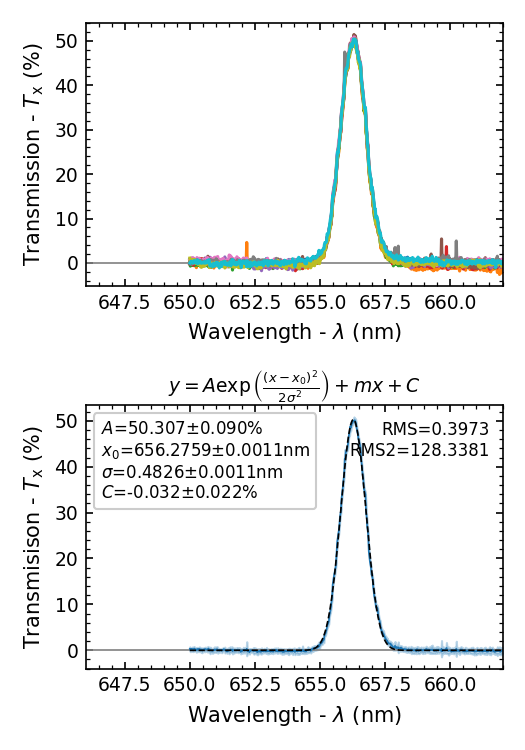

In [14]:
tx = (data - fit0[:,np.newaxis]) / (data2 - fit0[:,np.newaxis])

txMean = tx.mean(axis=1)
txStd = tx.std(axis=1)

def fitfunc(x, A, x0, sigma, C):
    return (A * np.exp(-(x - x0)**2 / (2. * sigma**2))) + C


popt, pcov = curve_fit(
    fitfunc, wl, txMean*100., sigma=txStd*100., 
    absolute_sigma=True, p0=(50., 656.1, 1.5, 0.)
)

pcov = np.sqrt(np.diag(pcov))
fit = fitfunc(wl, *popt)

sf = 2
dp = np.zeros(len(popt)).astype(int)
for i in range(0, len(popt)):
    dp[i] = sf - int(np.floor(np.log10(pcov[i]))) - 1

xlim2 = (646.,662.)
    

RMS = np.sqrt(np.mean(np.abs(fit - (txMean * 100.))**2))
RMS2 = np.sqrt(np.mean(np.abs((fit - (txMean * 100.)) / (txMean * 100.))**2))


####################################################################################


fig, ax = plt.subplots(2, 1, figsize=(3.5,5), dpi=150)
ax[0].plot(xlim2, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0].plot(wl, tx[:,i] * 100.)
ax[0].set_xlim(xlim2)
ax[0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0].set_ylabel('Transmission - $T_\\mathrm{x}$ (%)')
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()


ax[1].plot(xlim2, [0.,0.], '-', c='gray', lw=0.8)
ax[1].plot(wl, txMean * 100., '-', c='C0', lw=0.8)
ax[1].fill_between(
    wl, (txMean-txStd)*100., (txMean+txStd)*100., color='C0', alpha=0.3
)
ax[1].plot(
    wl, fit, '--', c='k', lw=0.8, 
    label=f'$A$={popt[0]:.{dp[0]}f}$\\pm${pcov[0]:.{dp[0]}f}%\n' + \
    f'$x_0$={popt[1]:.{dp[1]}f}$\\pm${pcov[1]:.{dp[1]}f}nm\n' + \
    f'$\\sigma$={popt[2]:.{dp[2]}f}$\\pm${pcov[2]:.{dp[2]}f}nm\n' + \
    f'$C$={popt[3]:.{dp[3]}f}$\\pm${pcov[3]:.{dp[3]}f}%'
)
ax[1].set_xlim(xlim2)
ax[1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1].set_ylabel('Transmisison - $T_\\mathrm{x}$ (%)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax[1].set_title('$y=A\\exp\\left(\\frac{(x-x_0)^2}{2\\sigma^2}\\right) + mx + C$', fontsize=9)
ax[1].text(661.5, 50., f'RMS={RMS:.4f}\nRMS2={RMS2:.4f}', ha='right', va='top', fontsize=8)


plt.tight_layout()
plt.savefig('./Plots/results_transmission_adjusted_const.png')

In [15]:
np.savez(
    '/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andoverCCFE_adjusted_c.npz', 
    wavelength = wl,
    transmission = txMean * 100.,
    transmissionStd = txStd * 100.,
)

np.savez(
    '/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andoverCCFE_adjusted_fit_c.npz', 
    wavelength = wl,
    transmission = fit,
)

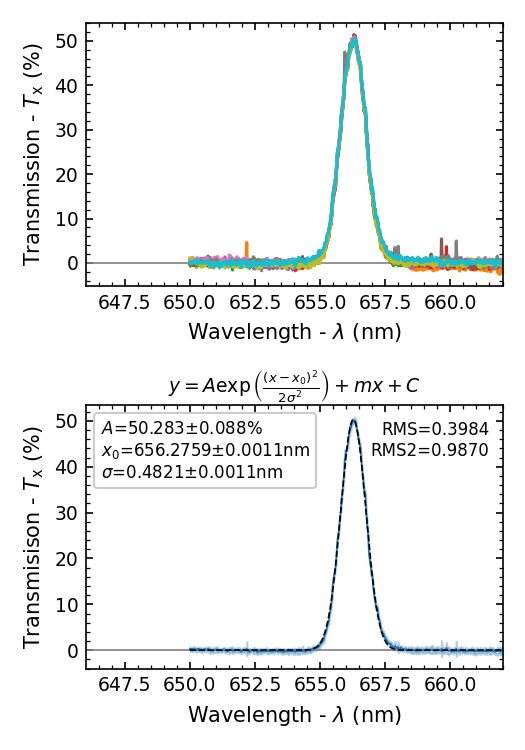

In [16]:
tx = (data - fit0[:,np.newaxis]) / (data2 - fit0[:,np.newaxis])

txMean = tx.mean(axis=1)
txStd = tx.std(axis=1)

def fitfunc(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2. * sigma**2))


popt, pcov = curve_fit(
    fitfunc, wl, txMean*100., sigma=txStd*100., 
    absolute_sigma=True, p0=(50., 656.1, 1.5)
)

pcov = np.sqrt(np.diag(pcov))
fit = fitfunc(wl, *popt)

sf = 2
dp = np.zeros(len(popt)).astype(int)
for i in range(0, len(popt)):
    dp[i] = sf - int(np.floor(np.log10(pcov[i]))) - 1

xlim2 = (646.,662.)
    

RMS = np.sqrt(np.mean(np.abs(fit - (txMean * 100.))**2))
RMS2 = np.sqrt(np.mean(np.abs((fit - (txMean * 100.)) / (txMean * 100.))**2))


####################################################################################


fig, ax = plt.subplots(2, 1, figsize=(3.5,5), dpi=150)
ax[0].plot(xlim2, [0.,0.], '-', c='gray', lw=0.8)
for i in range(0, 10):
    ax[0].plot(wl, tx[:,i] * 100.)
ax[0].set_xlim(xlim2)
ax[0].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[0].set_ylabel('Transmission - $T_\\mathrm{x}$ (%)')
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()


ax[1].plot(xlim2, [0.,0.], '-', c='gray', lw=0.8)
ax[1].plot(wl, txMean * 100., '-', c='C0', lw=0.8)
ax[1].fill_between(
    wl, (txMean-txStd)*100., (txMean+txStd)*100., color='C0', alpha=0.3
)
ax[1].plot(
    wl, fit, '--', c='k', lw=0.8, 
    label=f'$A$={popt[0]:.{dp[0]}f}$\\pm${pcov[0]:.{dp[0]}f}%\n' + \
    f'$x_0$={popt[1]:.{dp[1]}f}$\\pm${pcov[1]:.{dp[1]}f}nm\n' + \
    f'$\\sigma$={popt[2]:.{dp[2]}f}$\\pm${pcov[2]:.{dp[2]}f}nm'
)
ax[1].set_xlim(xlim2)
ax[1].set_xlabel('Wavelength - $\\lambda$ (nm)')
ax[1].set_ylabel('Transmisison - $T_\\mathrm{x}$ (%)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].legend(
    fancybox=1, framealpha=1, fontsize=8, 
    handlelength=0, handletextpad=0, labelcolor='linecolor'
)
ax[1].set_title('$y=A\\exp\\left(\\frac{(x-x_0)^2}{2\\sigma^2}\\right) + mx + C$', fontsize=9)
ax[1].text(661.5, 50., f'RMS={RMS:.4f}\nRMS2={RMS2:.4f}', ha='right', va='top', fontsize=8)


plt.tight_layout()
plt.savefig('./Plots/results_transmission_adjusted.png')

In [17]:
np.savez(
    '/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andoverCCFE_adjusted.npz', 
    wavelength = wl,
    transmission = txMean * 100.,
    transmissionStd = txStd * 100.,
)

np.savez(
    '/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andoverCCFE_adjusted_fit.npz', 
    wavelength = wl,
    transmission = fit,
)